In [33]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier

# Make plots look nice
plt.style.use('seaborn-v0_8')

# Load the dataset
df = pd.read_csv('framingham.csv')

# Check target distribution
df.drop('education', axis=1, inplace=True)
df.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [11]:
# Separate features (X) and target (y)
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Fill any missing numeric values with column means
X.fillna(X.mean(), inplace=True)
print("Number of features used:", X.shape[1])

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

Number of features used: 14


In [12]:
# Standardize the numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Best Threshold found: 0.57


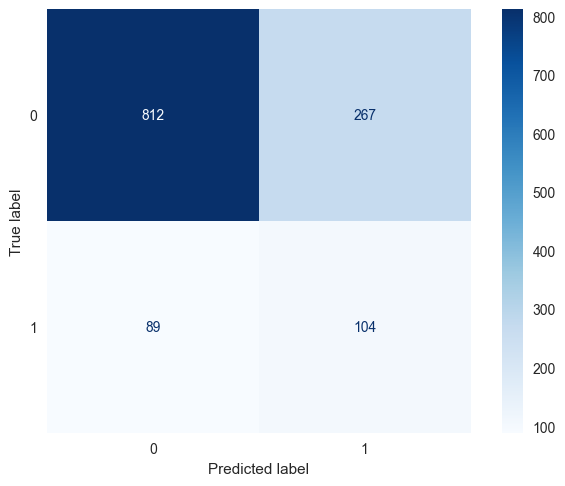

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1079
           1       0.28      0.54      0.37       193

    accuracy                           0.72      1272
   macro avg       0.59      0.65      0.59      1272
weighted avg       0.81      0.72      0.75      1272

Model Coefficients:
 age                0.606871
cigsPerDay         0.262820
sysBP              0.259720
male               0.242067
glucose            0.170291
prevalentHyp       0.090949
BMI                0.073988
prevalentStroke    0.067508
totChol            0.065545
diaBP              0.046180
BPMeds             0.036059
currentSmoker      0.035605
diabetes           0.018449
heartRate         -0.044772
dtype: float64
AUC Score:  0.7035683587278568


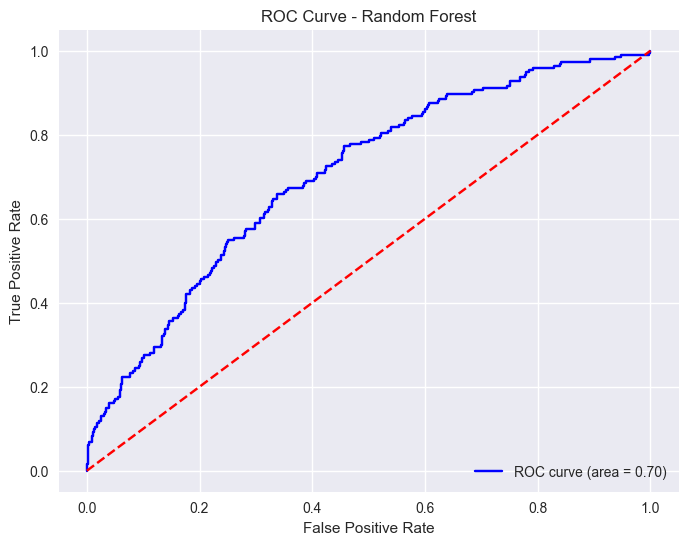

In [34]:
# Model 1 - Logistic Regression
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='liblinear'
)
model.fit(X_train_scaled, y_train)

# Predictions & probabilities
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Find optimal threshold
best_thresh = 0.5
best_f1 = 0
for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (y_proba >= thresh).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"Best Threshold found: {best_thresh:.2f}")

y_pred = (y_proba >= best_thresh).astype(int)

# Evaluation
confusion = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=confusion)
display.plot(cmap=plt.cm.Blues)
plt.grid(False)
plt.show()

print(classification_report(y_test, y_pred))

coefficients = pd.Series(model.coef_[0], index=X.columns)
print("Model Coefficients:\n", coefficients.sort_values(ascending=False))

# ROC curve & AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print("AUC Score: ", roc_auc)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1079
           1       0.26      0.50      0.34       193

    accuracy                           0.71      1272
   macro avg       0.58      0.62      0.58      1272
weighted avg       0.80      0.71      0.74      1272

Feature Importances:
 male               0.041880
age                0.242069
currentSmoker      0.013398
cigsPerDay         0.049619
BPMeds             0.003090
prevalentStroke    0.000000
prevalentHyp       0.051264
diabetes           0.001990
totChol            0.085015
sysBP              0.173295
diaBP              0.101410
BMI                0.091101
heartRate          0.064339
glucose            0.081531
dtype: float64
AUC Score:  0.6880579312066921


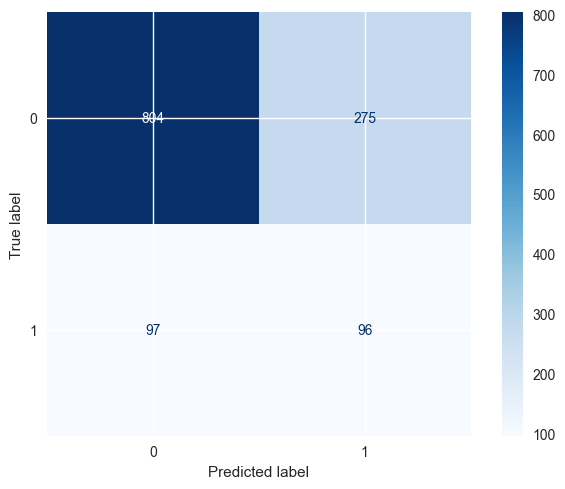

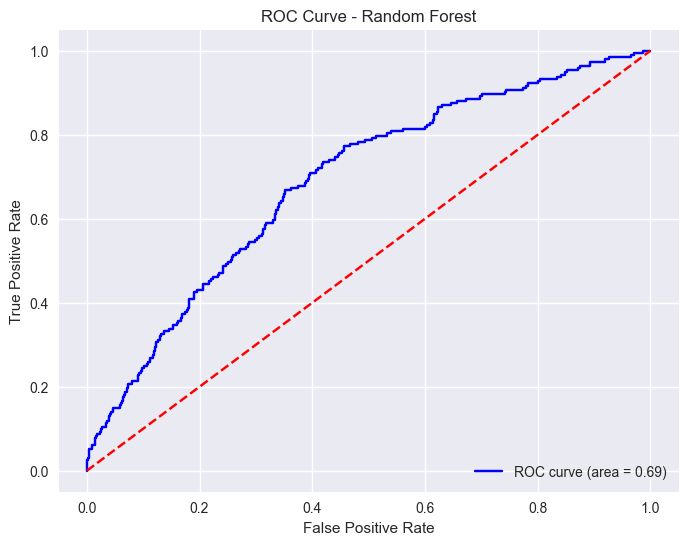

In [30]:
# Model 2 - Random Forest
model2 = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    min_samples_split=20,
    min_samples_leaf=20,
)
model2.fit(X_train, y_train)

# Predictions & probabilities
y_proba2 = model2.predict_proba(X_test)[:, 1]
threshold2 = 0.5
y_pred2 = (y_proba2 >= threshold2).astype(int)

# Evaluation metrics
confusion2 = confusion_matrix(y_test, y_pred2)
display2 = ConfusionMatrixDisplay(confusion_matrix=confusion2)
display2.plot(cmap=plt.cm.Blues)
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred2))

importances = pd.Series(model2.feature_importances_, index=X.columns)
print("Feature Importances:\n", importances)

# ROC curve & AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_proba2)
roc_auc = auc(fpr, tpr)
print("AUC Score: ", roc_auc)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()